In [5]:
from pathlib import Path
from dataclasses import dataclass, field
from collections import deque
from typing import List, Tuple
import time
import csv

import cv2
import numpy as np
from PIL import Image
from IPython.display import clear_output, display
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO


In [6]:
# Update these paths before running

IMAGE_DIR = Path("/work/DATA/2.2")
MODEL_PATH = Path("/work/droplet/model2/dataset/pretrainedWeight/best.pt")
OUTPUT_DIR = Path("/work/droplet/model2/output")
VIDEO_FILENAME = "droplet_paths.mp4"
CSV_FILENAME = "droplet_paths.csv"
START_IMAGE_NAME = None  # e.g. "0000613.png" to resume mid-sequence
START_AT_INDEX = 0  # ignored when START_IMAGE_NAME is provided

CONFIDENCE = 0.25
IOU_THRESHOLD = 0.3
MAX_MISSES = 5
DISPLAY_SCALE = 1.0
LINE_THICKNESS = 2
FRAME_DELAY = 0.15  # seconds between displayed frames
OUTPUT_FPS = 6.0
SUPPORTED_EXTS = (".png", ".jpg", ".jpeg", ".bmp")


In [7]:
PATH_HISTORY = None  # None keeps entire trajectory; set an int to limit stored points
TRACK_COLORS = [
    (239, 83, 80),
    (123, 31, 162),
    (30, 136, 229),
    (67, 160, 71),
    (255, 143, 0),
    (0, 151, 167),
]


def list_images(image_dir: Path) -> List[Path]:
    files = sorted(
        [p for p in Path(image_dir).iterdir() if p.suffix.lower() in SUPPORTED_EXTS]
    )
    if not files:
        raise FileNotFoundError(f"No images with {SUPPORTED_EXTS} found in {image_dir}")
    return files


def bbox_center(box: np.ndarray) -> Tuple[int, int]:
    x1, y1, x2, y2 = box
    return int((x1 + x2) / 2), int((y1 + y2) / 2)


def compute_iou(a: np.ndarray, b: np.ndarray) -> float:
    xA = max(a[0], b[0])
    yA = max(a[1], b[1])
    xB = min(a[2], b[2])
    yB = min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / float(area_a + area_b - inter)


@dataclass
class Track:
    id: int
    bbox: np.ndarray
    confidence: float
    misses: int = 0
    path: deque = field(default_factory=lambda: deque(maxlen=PATH_HISTORY))
    updated: bool = False

    def update(self, bbox: np.ndarray, confidence: float) -> None:
        self.bbox = bbox
        self.confidence = confidence
        self.misses = 0
        self.updated = True
        self.path.append(bbox_center(bbox))


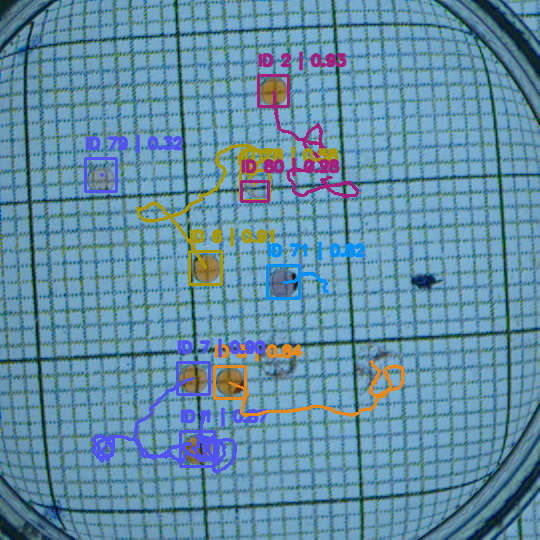

Frame: 0003909.png | Active tracks: 9
Saved annotated video to /work/droplet/model2/output/droplet_paths.mp4
Saved trajectory CSV to /work/droplet/model2/output/droplet_paths.csv


In [8]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
video_path = OUTPUT_DIR / VIDEO_FILENAME
csv_path = OUTPUT_DIR / CSV_FILENAME

model = YOLO(str(MODEL_PATH))
tracker = HungarianTracker(IOU_THRESHOLD, MAX_MISSES)
image_paths = list_images(IMAGE_DIR)

if START_IMAGE_NAME:
    matching = [idx for idx, path in enumerate(image_paths) if path.name == START_IMAGE_NAME]
    if not matching:
        raise ValueError(f"{START_IMAGE_NAME} not found in {IMAGE_DIR}")
    start_idx = matching[0]
else:
    start_idx = max(0, min(len(image_paths) - 1, START_AT_INDEX))

print(f"Tracking {len(image_paths) - start_idx} frames starting from {image_paths[start_idx].name}")

video_writer = None
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
path_records: List[Tuple[int, str, int, int, int]] = []
record_header = ["frame_number", "frame_name", "track_id", "x_center", "y_center"]

try:
    for frame_number, img_path in enumerate(image_paths[start_idx:], start=start_idx):
        frame = cv2.imread(str(img_path))
        if frame is None:
            print(f"Skipping unreadable frame: {img_path}")
            continue

        if video_writer is None:
            height, width = frame.shape[:2]
            video_writer = cv2.VideoWriter(str(video_path), fourcc, OUTPUT_FPS, (width, height))

        result = model.predict(source=frame, conf=CONFIDENCE, verbose=False)[0]
        detections = parse_detections(result, CONFIDENCE)
        tracks = tracker.update(detections)

        annotated = draw_tracks(frame, tracks)
        video_writer.write(annotated)

        for track in tracks:
            if track.updated:
                cx, cy = bbox_center(track.bbox)
                path_records.append((frame_number, img_path.name, track.id, cx, cy))

        display_frame = annotated
        if DISPLAY_SCALE != 1.0:
            display_frame = cv2.resize(
                annotated,
                None,
                fx=DISPLAY_SCALE,
                fy=DISPLAY_SCALE,
                interpolation=cv2.INTER_LINEAR,
            )

        rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))
        print(f"Frame: {img_path.name} | Active tracks: {len(tracks)}")
        time.sleep(FRAME_DELAY)
except KeyboardInterrupt:
    print("Tracking interrupted by user")
finally:
    if video_writer is not None:
        video_writer.release()
        print(f"Saved annotated video to {video_path}")
    if path_records:
        with open(csv_path, "w", newline="") as csv_file:
            writer = csv.writer(csv_file)
            writer.writerow(record_header)
            writer.writerows(path_records)
        print(f"Saved trajectory CSV to {csv_path}")


In [11]:
SPEEDUP_FACTOR = 2.5  # 2.0 = twice as fast
INPUT_VIDEO_PATH = OUTPUT_DIR / VIDEO_FILENAME  # point this to any .mp4 you want to accelerate
INPUT_VIDEO_PATH = Path(INPUT_VIDEO_PATH)

if not INPUT_VIDEO_PATH.exists():
    raise FileNotFoundError(f"Input video not found at {INPUT_VIDEO_PATH}")

OUTPUT_SPEED_VIDEO = INPUT_VIDEO_PATH.with_name(
    f"{INPUT_VIDEO_PATH.stem}_x{SPEEDUP_FACTOR:.1f}{INPUT_VIDEO_PATH.suffix}"
)

cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
orig_fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
if width == 0 or height == 0:
    cap.release()
    raise RuntimeError("Unable to read video metadata. Check the input file.")

new_fps = max(1.0, orig_fps * SPEEDUP_FACTOR)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_SPEED_VIDEO), fourcc, new_fps, (width, height))

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    writer.write(frame)
    frame_count += 1

cap.release()
writer.release()
print(
    f"Wrote {frame_count} frames to {OUTPUT_SPEED_VIDEO} at {new_fps:.2f} fps (speed x{SPEEDUP_FACTOR})."
)


Wrote 3365 frames to /work/droplet/model2/output/droplet_paths_x2.5.mp4 at 15.00 fps (speed x2.5).
